# Benchmark Problems Example

`smt-optim` comes with many test problems for benchmarking. This notebook shows how to get the problems, filter them and plot them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim.benchmarks.registry import list_problems

## Overview

The `list_problems` method allows us to retrieve a list of `BenchmarkProblem` problems with specific attributes. If no attributes are given, it will return all the problems implemented in `smt-optim`. The example below, first all problems are fetch. Then only problems of dimension 2 present in the SFU collection are fetched. The parameter `n`, which corresponds to the number of variable, expects a lower and upper bound.

In [2]:
problems = list_problems()
print("Number of problem found:", len(problems))

problems = list_problems(n=[2, 2], tags=["sfu"])
print("Number of problem found:", len(problems))

Number of problem found: 36
Number of problem found: 10


The `BenchmarkProblem` class has several key attributes:
- `num_dim`: The number of dimensions
- `num_obj`: The number of objectives
- `num_cstr`: The number of constraints
- `num_fidelity`: The number of fidelity levels (for multi-fidelity problems)
- `bounds`: The variable bounds

For mono-fidelity `BenchmarkProblem`s, the objective function can be evaluated using the `objective` class method. Here's an example code snippet that plots 3 problems on their respective domains:

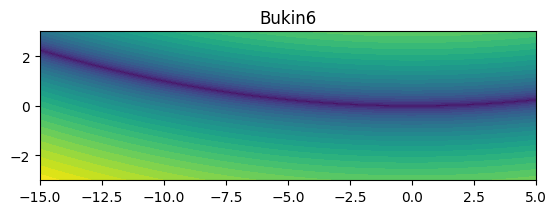

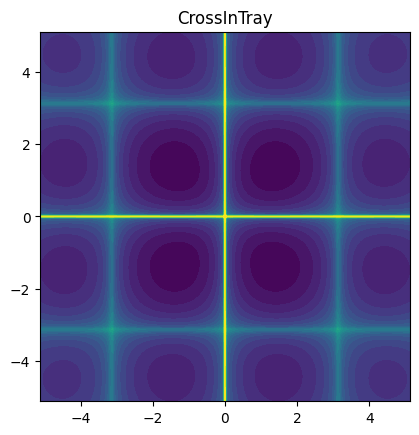

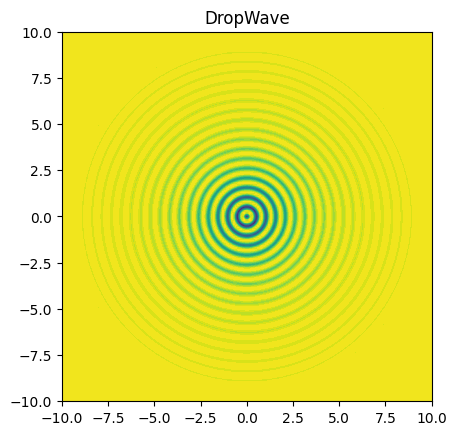

In [3]:
num_display = 3

for idx, prob in enumerate(problems):
    X = np.linspace(prob.bounds[0, 0], prob.bounds[0, 1], 201)
    Y = np.linspace(prob.bounds[1, 0], prob.bounds[1, 1], 201)
    XX, YY = np.meshgrid(X, Y)

    data = np.vstack((XX.ravel(), YY.ravel())).T
    z = np.empty(data.shape[0])

    for i in range(data.shape[0]):
        z[i] = prob.objective(data[i, :])

    Z = z.reshape(XX.shape)

    fig, ax = plt.subplots()
    ax.contourf(XX, YY, Z, levels=30)
    ax.set_title(prob.name)
    ax.set_aspect('equal')

    plt.show()

    if idx+1 >= num_display:
        break


## Multi-fidelity Benchmark Problems

The code snippet below retrieves and plots all 1D and 2D multi-fidelity analytical benchmark problems from the AVT-311 L1 benchmarks. Note that for multi-fidelity problems, the `objectives` attribute returns a list of callable objective functions in increasing order of fidelity.

Number of problem found: 6


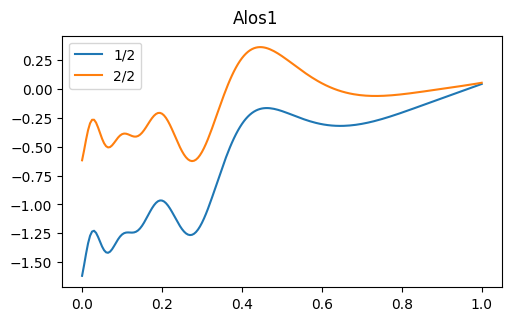

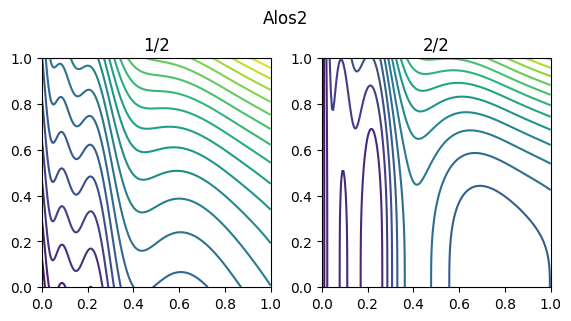

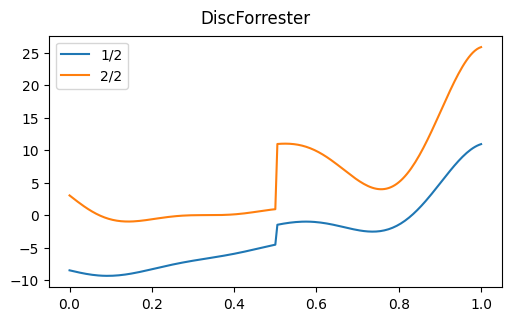

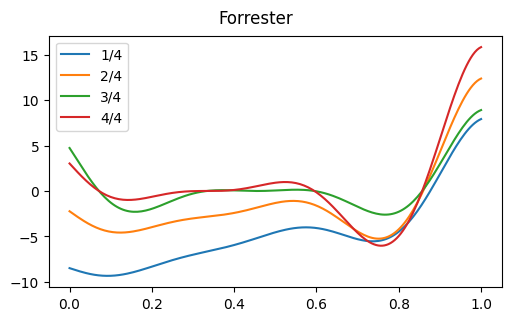

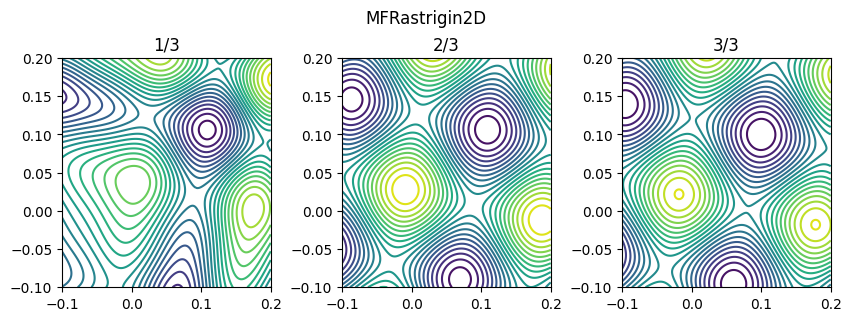

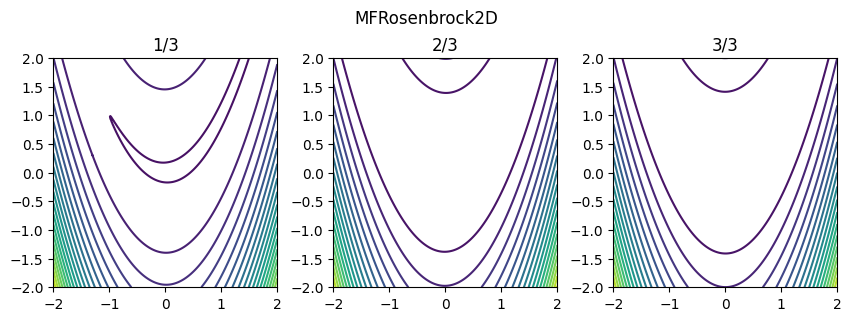

In [4]:
problems = list_problems(n=[1, 2], tags=["avt311"])
print("Number of problem found:", len(problems))

for prob in problems:

    if prob.num_dim == 1:

        fig, ax = plt.subplots(layout="constrained", figsize=(5, 3.1))
        fig.suptitle(prob.name)
        x = np.linspace(prob.bounds[0, 0], prob.bounds[0, 1], 201)

        for lvl in range(prob.num_fidelity):
            z = np.empty_like(x)

            for idx in range(x.shape[0]):
                z[idx] = prob.objectives[lvl](x[idx])

            ax.plot(x, z, label=f"{lvl+1}/{prob.num_fidelity}")

        ax.legend()
        plt.show()

    elif prob.num_dim == 2:
        X = np.linspace(prob.bounds[0, 0], prob.bounds[0, 1], 201)
        Y = np.linspace(prob.bounds[1, 0], prob.bounds[1, 1], 201)
        XX, YY = np.meshgrid(X, Y)

        data = np.vstack((XX.ravel(), YY.ravel())).T
        z = np.empty(data.shape[0])

        fig, ax = plt.subplots(1, prob.num_fidelity, layout="constrained", figsize=(2.8*prob.num_fidelity, 3.1))
        fig.suptitle(prob.name)

        for lvl in range(prob.num_fidelity):
            for i in range(data.shape[0]):
                z[i] = prob.objectives[lvl](data[i, :])
            Z = z.reshape(XX.shape)
            ax[lvl].contour(XX, YY, Z, levels=20)
            ax[lvl].set_title(f"{lvl+1}/{prob.num_fidelity}")
            # ax[lvl].set_aspect('equal')

        plt.show()
